In [ ]:
import pandas as pd
import numpy as nb 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"F:\ML\projects\project2\train.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170884 entries, 0 to 170883
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170884 non-null  float64
 1   V1      170884 non-null  float64
 2   V2      170884 non-null  float64
 3   V3      170884 non-null  float64
 4   V4      170884 non-null  float64
 5   V5      170884 non-null  float64
 6   V6      170884 non-null  float64
 7   V7      170884 non-null  float64
 8   V8      170884 non-null  float64
 9   V9      170884 non-null  float64
 10  V10     170884 non-null  float64
 11  V11     170884 non-null  float64
 12  V12     170884 non-null  float64
 13  V13     170884 non-null  float64
 14  V14     170884 non-null  float64
 15  V15     170884 non-null  float64
 16  V16     170884 non-null  float64
 17  V17     170884 non-null  float64
 18  V18     170884 non-null  float64
 19  V19     170884 non-null  float64
 20  V20     170884 non-null  float64
 21  V21     17

In [5]:
df.isnull().sum().sum()

np.int64(0)

No null values

In [6]:
df.duplicated().sum()

np.int64(448)

In [7]:
df.drop_duplicates(inplace=True)

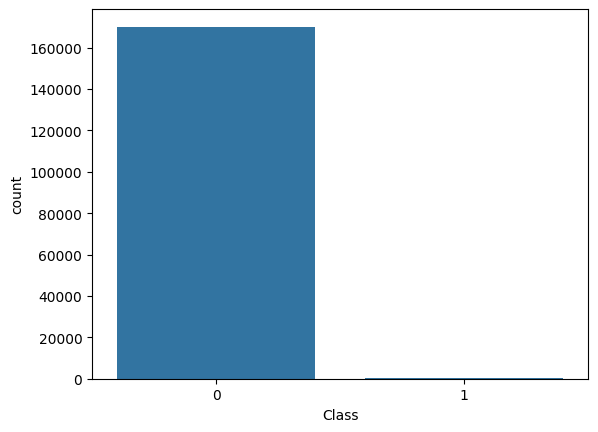

In [8]:
sns.countplot(data=df,x="Class")
plt.show()

In [9]:
df["Class"].value_counts()

Class
0    170139
1       297
Name: count, dtype: int64

this imblanced data set and must use precision and recall more than accurecy

These operations take place over two days, and it doesn't matter whether the operation occurred on the first or second day. What matters is the time. So, any operation that occurred on the second day will be subtracted from the total seconds of the first day to standardize the operations. That is, if an operation occurred two seconds later on the first day, it will be similar to one that occurred at the same time on the second day.

In [10]:
df["Time"]=df["Time"]%86400

In [11]:
df["Hour"]=(df["Time"]//3600).astype(int)

In [12]:
df["Hour"].unique()

array([ 9, 19, 18, 15, 14,  0, 21, 22,  2, 13,  8,  1,  7, 12, 10, 20, 11,
       17, 16,  6,  5, 23,  3,  4])

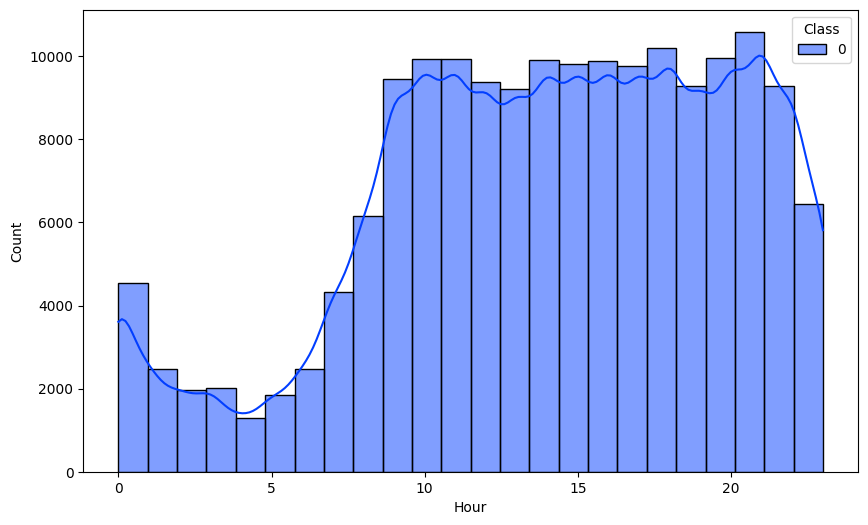

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df[df["Class"]==0], x="Hour", hue="Class",palette='bright', kde=True,bins=24)

plt.show()

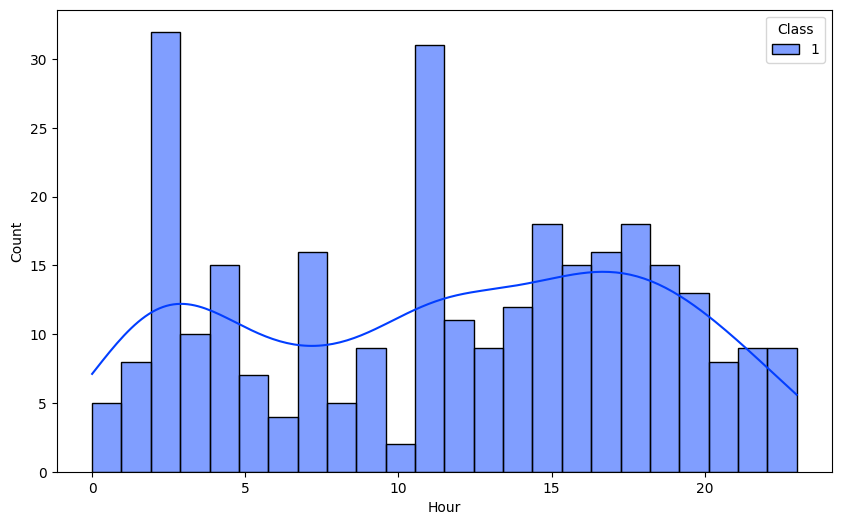

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df[df["Class"]==1], x="Hour", hue="Class",palette='bright', kde=True,bins=24)

plt.show()

Fraud increases at 2 and 11 o'clock, and also increases relatively between 3 and 8 o'clock, which shows that time plays an important role.

c:\Users\ms\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


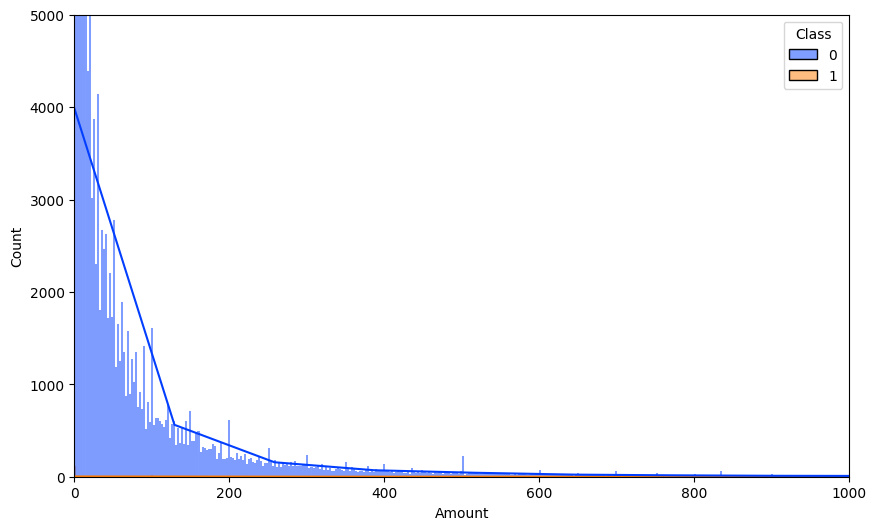

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Amount", hue="Class",palette='bright', kde=True)
plt.ylim(0, 5000)
plt.xlim(0,1000)
plt.show()

In [16]:
df[df["Amount"]<100]["Class"].value_counts()

Class
0    135680
1       217
Name: count, dtype: int64

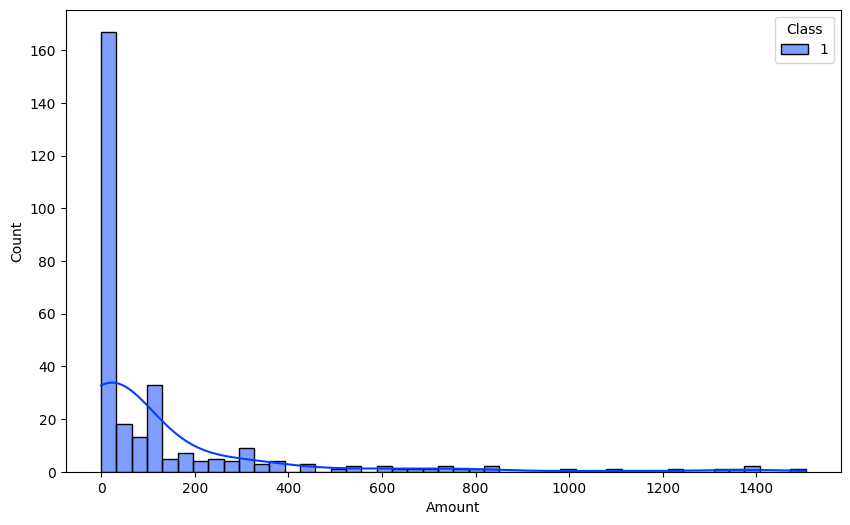

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df[df["Class"]==1], x="Amount", hue="Class",palette='bright', kde=True)

plt.show()

There is a striking similarity in financial behavior between legitimate and fraudulent transactions, with the average fraudulent transaction costing $16 compared to $20 for a legitimate transaction. This suggests a strategy of "behavioral camouflage" employed by fraudsters to blend into the victim's usual purchasing range.

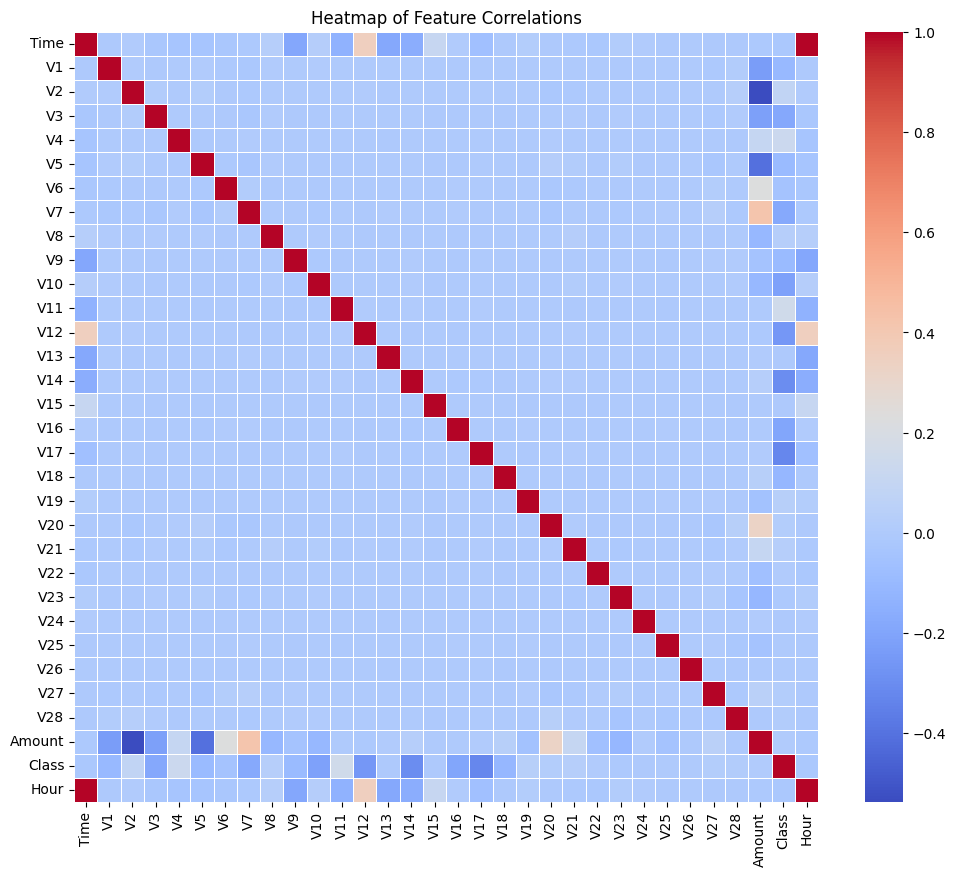

In [22]:
corr = df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=.5)

plt.title('Heatmap of Feature Correlations')
plt.show()

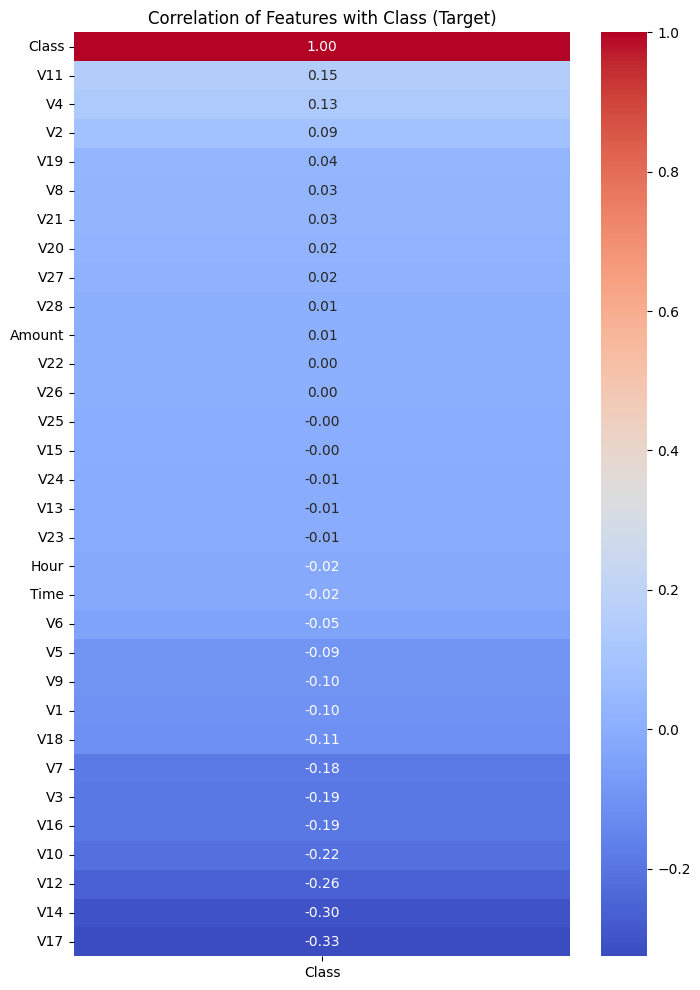

In [23]:
plt.figure(figsize=(8, 12))

# حساب الارتباط مع عمود Class وترتيبه
target_corr = df.corr()[['Class']].sort_values(by='Class', ascending=False)

# رسم هيت ماب لعمود واحد فقط (أكثر وضوحاً للتقرير)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation of Features with Class (Target)')
plt.show()

Feature Importance: "Correlationship analysis showed that variables V17, V14, and V12 are the most predictive of fraud due to their strong inverse correlation with the dependent variable (Class)."

Multivariate Necessity: "Since the single correlations do not exceed 0.33, this confirms that fraud cannot be detected by a single variable alone, but requires machine learning models capable of understanding complex relationships between multiple variables simultaneously (non-linear relationships)."

Data Ready for Modeling: "Based on these results, the data is ready for modeling, focusing on the top 10 variables that appeared in the correlation map to ensure the model's efficiency."

C:\Users\ms\AppData\Local\Temp\ipykernel_3976\3475609718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feature, data=df, palette='bright', ax=axes[i])
C:\Users\ms\AppData\Local\Temp\ipykernel_3976\3475609718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feature, data=df, palette='bright', ax=axes[i])
C:\Users\ms\AppData\Local\Temp\ipykernel_3976\3475609718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y=feature, data=df, palette='bright', ax=axes[i])
C:\Users\ms\AppData\Local\Temp\ipyker

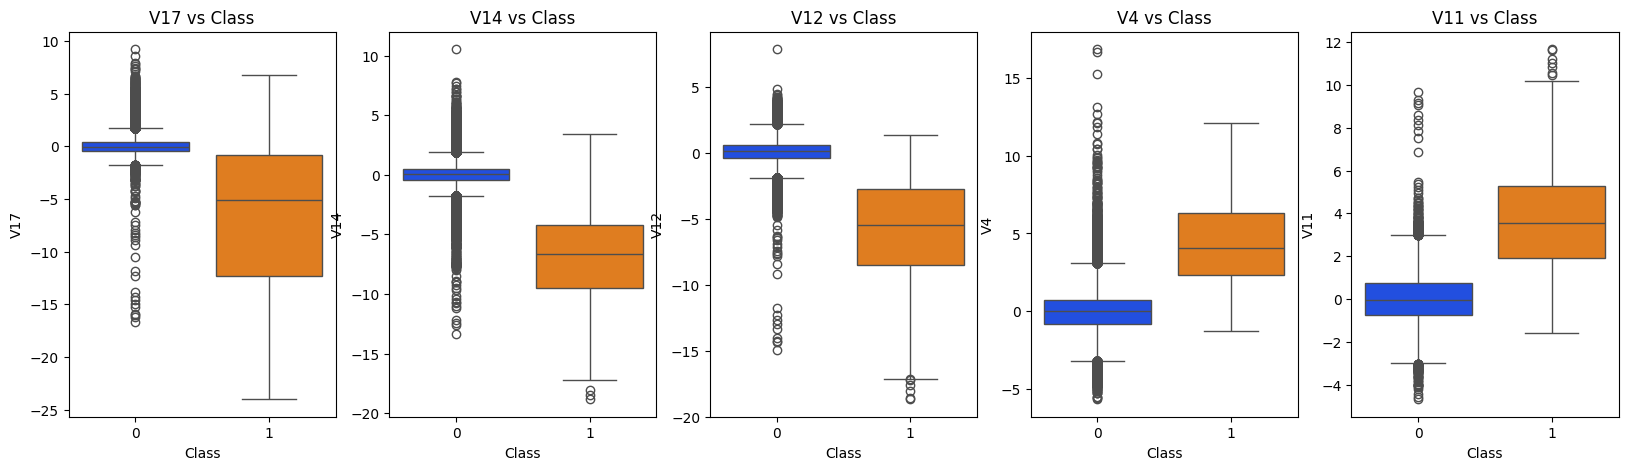

In [25]:

top_features = ['V17', 'V14', 'V12', 'V4','V11']

f, axes = plt.subplots(ncols=5, figsize=(20, 5))

for i, feature in enumerate(top_features):
    sns.boxplot(x="Class", y=feature, data=df, palette='bright', ax=axes[i])
    axes[i].set_title(f'{feature} vs Class')

plt.show()